# Compare LV4 grid: original vs h_min=0.5 m patched

The operational LV4 grid `GRID_SDTJRE_LV4_mss_oct2024.nc` had wet cells with negative `h` (up to `h = -1.49 m`). Those intertidal mudflats broke sigma-coord ROMS.

The patched grid `GRID_SDTJRE_LV4_mss_oct2024_hmin0p5.nc` was produced by:

```python
h_new = np.maximum(h_old, 0.5)
```

— i.e. any cell with `h < 0.5` was raised to `h = 0.5`; everything else is untouched. `mask_rho / mask_u / mask_v / mask_psi` are unchanged, so no cell became wet/dry.

This notebook loads both grids and shows where the changes are, in both lat/lon and i/j.

In [19]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fn_old = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc'
fn_new = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024_hmin0p5.nc'

with nc.Dataset(fn_old) as d:
    h_old = np.asarray(d.variables['h'][:])
    mask  = np.asarray(d.variables['mask_rho'][:]).astype(int)
    lon   = np.asarray(d.variables['lon_rho'][:])
    lat   = np.asarray(d.variables['lat_rho'][:])
with nc.Dataset(fn_new) as d:
    h_new = np.asarray(d.variables['h'][:])

dh    = h_new - h_old                # 0 where nothing changed, > 0 where raised
wet   = (mask == 1)

ny, nx = h_old.shape
print(f'grid shape (eta, xi) = {(ny, nx)}   wet cells = {int(wet.sum()):,}')
print(f'h_old  min(wet) = {h_old[wet].min():7.3f} m   max = {h_old[wet].max():.1f} m')
print(f'h_new  min(wet) = {h_new[wet].min():7.3f} m   max = {h_new[wet].max():.1f} m')
print(f'')
print(f'cells raised (dh > 0)              : {int((dh > 0).sum()):,}   ({100*(dh>0).sum()/dh.size:.2f}% of all cells)')
print(f'  ...wet cells raised              : {int(((dh > 0) & wet).sum()):,}   ({100*((dh>0) & wet).sum()/wet.sum():.2f}% of wet cells)')
print(f'  ...dry (land) cells raised       : {int(((dh > 0) & ~wet).sum()):,}   (cosmetic; land h has no dynamical effect)')
print(f'')
print(f'per-changed-wet-cell dh: min = {dh[(dh>0) & wet].min():.3f} m   '
      f'max = {dh[(dh>0) & wet].max():.3f} m   mean = {dh[(dh>0) & wet].mean():.3f} m')

grid shape (eta, xi) = (1141, 486)   wet cells = 393,202
h_old  min(wet) =  -1.495 m   max = 76.7 m
h_new  min(wet) =   0.500 m   max = 76.7 m

cells raised (dh > 0)              : 180,091   (32.48% of all cells)
  ...wet cells raised              : 22,834   (5.81% of wet cells)
  ...dry (land) cells raised       : 157,257   (cosmetic; land h has no dynamical effect)

per-changed-wet-cell dh: min = 0.000 m   max = 1.995 m   mean = 0.870 m


## 0. Horizontal bathymetry gradients — is that the real problem?

The `h < 0` wet cells aren't actually a problem — LV4 uses `WET_DRY` (Dcrit = 0.35 m) so those intertidal mudflats are intentional. King tides on 2026-07-12 are the more likely trigger for last night's blowup.

But the user recalls patching the LV4 grid around **ROMS (i, j) = (430, 800)** to fix *large horizontal gradients* — a different pathology. Sigma-coordinate pressure-gradient error grows with `rx0 = |Δh|/(h₁+h₂)`; the standard "safe" ceiling is `rx0 ≤ 0.2` and grid names like `hplus020` / `rx020` seem to advertise exactly that.

Below:
1. compute `|Δh|` and `rx0` at every rho point (worst-neighbor aggregation),
2. print the top-N offending wet cells and the values at the two anchor points (LV4 blowup + user-recalled patch region),
3. plot both metrics in **lat/lon** and **i/j** with markers at those two anchors,
4. zoom to a 31×31 window around the user-recalled `(430, 800)`.

If we see a cluster of high-`rx0` cells near `(430, 800)`, that's likely what the previous patch was about — and a targeted local smoothing/mask fix is a reasonable move.

|dh|_max  over wet points   =  24.244 m
rx0_max   over wet points   =   1.000
wet cells with rx0 > 0.20   : 19,863
wet cells with rx0 > 0.35   : 12,894
wet cells with |dh| > 1 m   : 17,165

top 12 wet cells by |dh|:
    py (i,j)     ROMS (i,j)        lon       lat        h        |dh|  mask
  ( 20, 140)  ( 21, 141)  -117.2079   32.4486   46.192     24.2441  1
  ( 21, 140)  ( 22, 141)  -117.2071   32.4487   70.436     24.2441  1
  ( 21, 133)  ( 22, 134)  -117.2068   32.4469   51.928     23.8195  1
  ( 22, 133)  ( 23, 134)  -117.2061   32.4470   75.747     23.8195  1
  ( 23, 139)  ( 24, 140)  -117.2056   32.4486   45.097     23.6966  1
  ( 22, 139)  ( 23, 140)  -117.2063   32.4485   68.794     23.6966  1
  ( 23, 140)  ( 24, 141)  -117.2056   32.4489   44.995     23.6456  1
  ( 22, 140)  ( 23, 141)  -117.2064   32.4488   68.641     23.6456  1
  ( 19, 119)  ( 20, 120)  -117.2077   32.4431   44.822     23.5593  1
  ( 18, 119)  ( 19, 120)  -117.2085   32.4430   68.382     23.5593  1
  ( 18, 

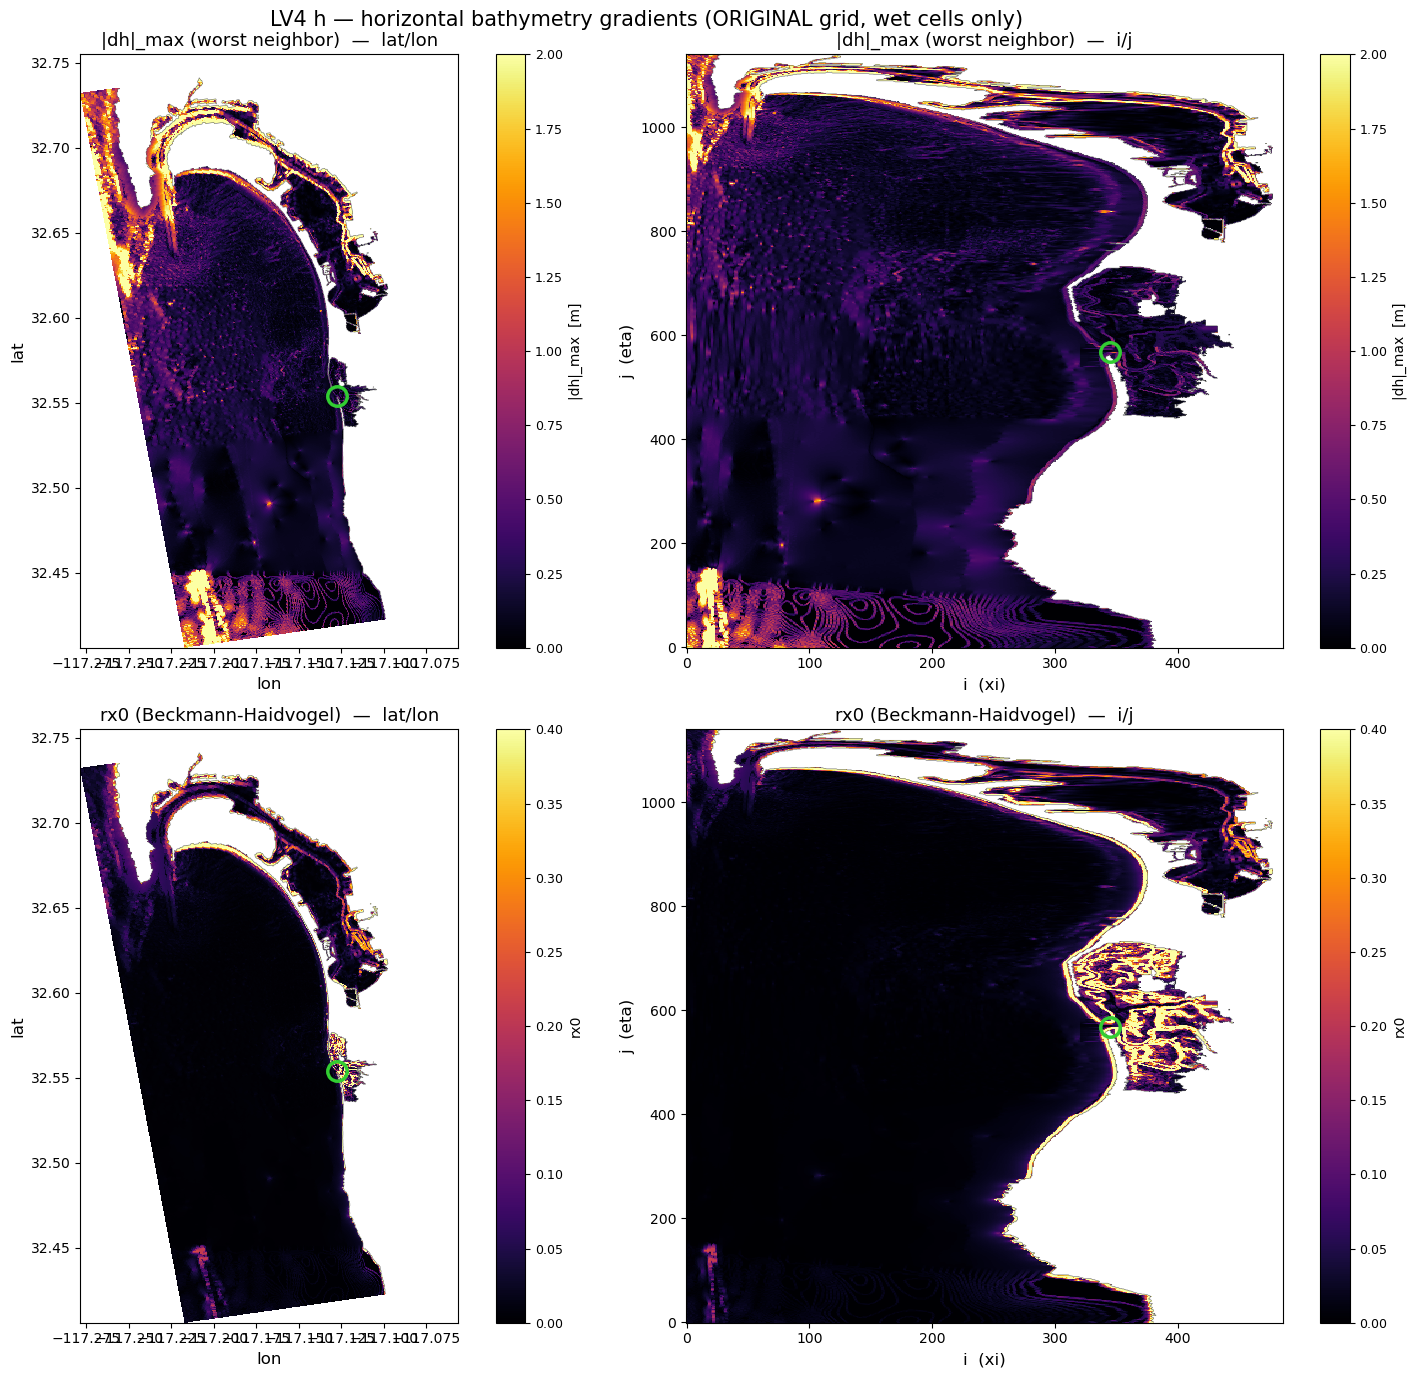

In [20]:
# --- compute horizontal bathymetry gradients on the ORIGINAL LV4 grid ---
# raw |dh| in metres, at u-edges (xi direction) and v-edges (eta direction)
dh_xi  = np.abs(h_old[:,  1:] - h_old[:,  :-1])     # shape (ny,   nx-1)
dh_eta = np.abs(h_old[1:, :]  - h_old[:-1, :])      # shape (ny-1, nx)

# rx0 (Beckmann-Haidvogel steepness), safe denominator
def rx0_edge(a, b):
    den = np.abs(a) + np.abs(b)
    return np.where(den > 1e-6, np.abs(a - b) / den, 0.0)

rx0_xi_e  = rx0_edge(h_old[:,  1:], h_old[:,  :-1])
rx0_eta_e = rx0_edge(h_old[1:, :],  h_old[:-1, :])

# aggregate to each rho point (worst of its 4 edges)
rx0_rho = np.zeros_like(h_old)
rx0_rho[:, 1:-1] = np.maximum(rx0_xi_e[:, :-1],  rx0_xi_e[:, 1:])
rx0_rho[1:-1, :] = np.maximum(rx0_rho[1:-1, :],
                              np.maximum(rx0_eta_e[:-1, :], rx0_eta_e[1:, :]))
rx0_rho[:, 0]    = rx0_xi_e[:, 0]
rx0_rho[:, -1]   = rx0_xi_e[:, -1]
rx0_rho[0, :]    = np.maximum(rx0_rho[0, :],  rx0_eta_e[0, :])
rx0_rho[-1, :]   = np.maximum(rx0_rho[-1, :], rx0_eta_e[-1, :])

# raw |dh| aggregated the same way
dh_rho = np.zeros_like(h_old)
dh_rho[:, 1:-1] = np.maximum(dh_xi[:, :-1], dh_xi[:, 1:])
dh_rho[1:-1, :] = np.maximum(dh_rho[1:-1, :],
                             np.maximum(dh_eta[:-1, :], dh_eta[1:, :]))
dh_rho[:, 0]    = dh_xi[:, 0]
dh_rho[:, -1]   = dh_xi[:, -1]
dh_rho[0, :]    = np.maximum(dh_rho[0, :],  dh_eta[0, :])
dh_rho[-1, :]   = np.maximum(dh_rho[-1, :], dh_eta[-1, :])

# --- summary + top offenders ---
def show_top_N(name, arr, N=15, wet_only=True):
    a = np.where(mask == 1, arr, -np.inf) if wet_only else arr
    flat = a.flatten()
    order = np.argsort(-flat)[:N]
    ys, xs = np.unravel_index(order, arr.shape)
    print(f'\ntop {N} {"wet " if wet_only else ""}cells by {name}:')
    print(f'  {"py (i,j)":>10s}  {"ROMS (i,j)":>13s}  {"lon":>9s}  {"lat":>8s}  '
          f'{"h":>7s}  {name:>10s}  mask')
    for k in range(N):
        y, x = ys[k], xs[k]
        print(f'  ({x:3d},{y:4d})  ({x+1:3d},{y+1:4d})  {lon[y,x]:9.4f}  '
              f'{lat[y,x]:8.4f}  {h_old[y,x]:7.3f}  {arr[y,x]:10.4f}  {mask[y,x]}')

print(f'|dh|_max  over wet points   = {dh_rho[mask==1].max():7.3f} m')
print(f'rx0_max   over wet points   = {rx0_rho[mask==1].max():7.3f}')
print(f'wet cells with rx0 > 0.20   : {int(((rx0_rho > 0.20) & (mask == 1)).sum()):,}')
print(f'wet cells with rx0 > 0.35   : {int(((rx0_rho > 0.35) & (mask == 1)).sum()):,}')
print(f'wet cells with |dh| > 1 m   : {int(((dh_rho  > 1.0)  & (mask == 1)).sum()):,}')

show_top_N('|dh|',  dh_rho,  N=12, wet_only=True)
show_top_N('rx0',   rx0_rho, N=12, wet_only=True)

# --- LV4 blowup + user-recalled patch cell (both in ROMS 1-idx) ---
BU_I_ROMS, BU_J_ROMS = 346, 570         # from LV4_forecast.log step 103068
USER_I_ROMS, USER_J_ROMS = 430, 800     # user's recalled patch region
BU_I, BU_J     = BU_I_ROMS - 1,   BU_J_ROMS - 1
USER_I, USER_J = USER_I_ROMS - 1, USER_J_ROMS - 1

print(f'\nLV4 blowup (ROMS {BU_I_ROMS},{BU_J_ROMS}):    '
      f'h={h_old[BU_J, BU_I]:.3f}  |dh|_local={dh_rho[BU_J, BU_I]:.3f}  '
      f'rx0_local={rx0_rho[BU_J, BU_I]:.3f}')
print(f'user recalled patch (ROMS {USER_I_ROMS},{USER_J_ROMS}): '
      f'h={h_old[USER_J, USER_I]:.3f}  |dh|_local={dh_rho[USER_J, USER_I]:.3f}  '
      f'rx0_local={rx0_rho[USER_J, USER_I]:.3f}')

# --- domain-wide plots: |dh| and rx0, in lat/lon and in i/j ---
LBL_FS, TICK_FS, TITLE_FS = 12, 10, 14

# mask everything but wet cells for display
def wet_only(a): return np.where(mask == 1, a, np.nan)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# row 0: |dh|
for col, coord in enumerate(('lat/lon', 'i/j')):
    ax = axes[0, col]
    if coord == 'lat/lon':
        pc = ax.pcolormesh(lon, lat, wet_only(dh_rho), cmap='inferno',
                           vmin=0, vmax=2.0, shading='auto')
        ax.contour(lon, lat, mask, levels=[0.5], colors='0.4', linewidths=0.4)
        ax.plot(lon[BU_J,   BU_I],   lat[BU_J,   BU_I],   'o', ms=14, mfc='none',
                mec='limegreen', mew=2.5)
        ax.set_xlabel('lon', fontsize=LBL_FS); ax.set_ylabel('lat', fontsize=LBL_FS)
        ax.set_aspect('equal')
    else:
        pc = ax.imshow(wet_only(dh_rho), origin='lower', cmap='inferno', vmin=0, vmax=2.0,
                       interpolation='nearest', aspect='auto')
        ax.contour(np.arange(nx), np.arange(ny), mask, levels=[0.5],
                   colors='0.4', linewidths=0.4)
        ax.plot(BU_I, BU_J, 'o', ms=14, mfc='none', mec='limegreen', mew=2.5)
        ax.set_xlabel('i  (xi)', fontsize=LBL_FS); ax.set_ylabel('j  (eta)', fontsize=LBL_FS)
    cb = fig.colorbar(pc, ax=ax, label='|dh|_max  [m]')
    cb.ax.tick_params(labelsize=TICK_FS-1)
    ax.set_title(f'|dh|_max (worst neighbor)  —  {coord}', fontsize=TITLE_FS-1)
    ax.tick_params(labelsize=TICK_FS)

# row 1: rx0
for col, coord in enumerate(('lat/lon', 'i/j')):
    ax = axes[1, col]
    if coord == 'lat/lon':
        pc = ax.pcolormesh(lon, lat, wet_only(rx0_rho), cmap='inferno',
                           vmin=0, vmax=0.4, shading='auto')
        ax.contour(lon, lat, mask, levels=[0.5], colors='0.4', linewidths=0.4)
        ax.plot(lon[BU_J,   BU_I],   lat[BU_J,   BU_I],   'o', ms=14, mfc='none',
                mec='limegreen', mew=2.5)
        ax.set_xlabel('lon', fontsize=LBL_FS); ax.set_ylabel('lat', fontsize=LBL_FS)
        ax.set_aspect('equal')
    else:
        pc = ax.imshow(wet_only(rx0_rho), origin='lower', cmap='inferno', vmin=0, vmax=0.4,
                       interpolation='nearest', aspect='auto')
        ax.contour(np.arange(nx), np.arange(ny), mask, levels=[0.5],
                   colors='0.4', linewidths=0.4)
        ax.plot(BU_I, BU_J, 'o', ms=14, mfc='none', mec='limegreen', mew=2.5)
        ax.set_xlabel('i  (xi)', fontsize=LBL_FS); ax.set_ylabel('j  (eta)', fontsize=LBL_FS)
    cb = fig.colorbar(pc, ax=ax, label='rx0')
    cb.ax.tick_params(labelsize=TICK_FS-1)
    ax.set_title(f'rx0 (Beckmann-Haidvogel)  —  {coord}', fontsize=TITLE_FS-1)
    ax.tick_params(labelsize=TICK_FS)

fig.suptitle('LV4 h — horizontal bathymetry gradients (ORIGINAL grid, wet cells only)',
             fontsize=TITLE_FS+1)
fig.tight_layout()
plt.show()

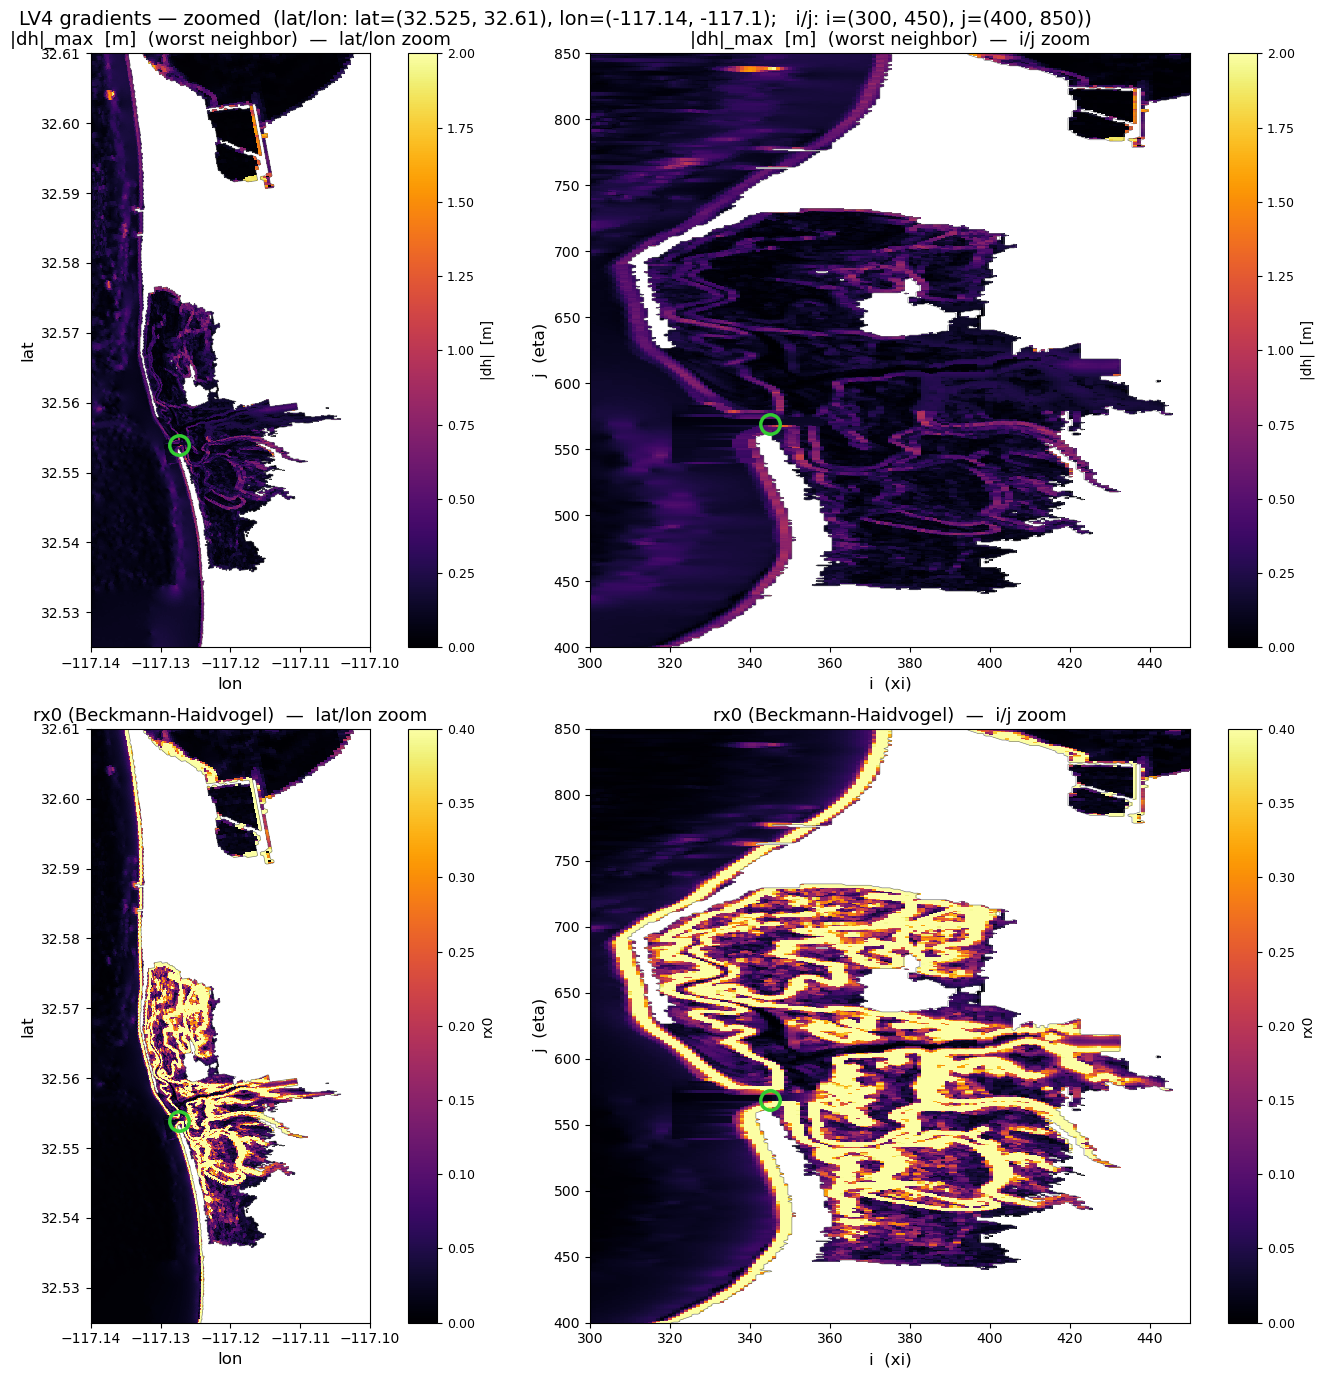

In [ ]:
# Same 2x2 view as above, zoomed to specific windows:
#   lat/lon window: lat = [32.525, 32.610],  lon = [-117.14, -117.10]
#   i/j     window: j   = [400, 850],        i   = [300, 450]
# (independent windows — they may not cover the same physical area.)

LL_YLIM = (32.525, 32.610)
LL_XLIM = (-117.14, -117.10)
IJ_YLIM = (400, 850)
IJ_XLIM = (300, 450)

LBL_FS, TICK_FS, TITLE_FS = 12, 10, 14

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

specs = [
    (dh_rho,  '|dh|_max  [m]  (worst neighbor)', 'inferno', 0, 2.0, '|dh|  [m]'),
    (rx0_rho, 'rx0 (Beckmann-Haidvogel)',        'inferno', 0, 0.4, 'rx0'),
]

for row, (field, ttl, cmap, vmn, vmx, lbl) in enumerate(specs):
    # left column: lat/lon
    ax = axes[row, 0]
    pc = ax.pcolormesh(lon, lat, wet_only(field), cmap=cmap, vmin=vmn, vmax=vmx,
                       shading='auto')
    ax.contour(lon, lat, mask, levels=[0.5], colors='0.4', linewidths=0.4)
    ax.plot(lon[BU_J, BU_I],     lat[BU_J, BU_I],     'o', ms=14, mfc='none',
            mec='limegreen', mew=2.5)
    cb = fig.colorbar(pc, ax=ax, label=lbl)
    cb.ax.tick_params(labelsize=TICK_FS-1)
    ax.set_xlim(LL_XLIM); ax.set_ylim(LL_YLIM)
    ax.set_xlabel('lon', fontsize=LBL_FS); ax.set_ylabel('lat', fontsize=LBL_FS)
    ax.set_title(f'{ttl}  —  lat/lon zoom', fontsize=TITLE_FS-1)
    ax.tick_params(labelsize=TICK_FS)
    ax.set_aspect('equal')

    # right column: i/j
    ax = axes[row, 1]
    pc = ax.imshow(wet_only(field), origin='lower', cmap=cmap, vmin=vmn, vmax=vmx,
                   interpolation='nearest', aspect='auto')
    ax.contour(np.arange(nx), np.arange(ny), mask, levels=[0.5],
               colors='0.4', linewidths=0.4)
    ax.plot(BU_I, BU_J, 'o', ms=14, mfc='none', mec='limegreen', mew=2.5)
    cb = fig.colorbar(pc, ax=ax, label=lbl)
    cb.ax.tick_params(labelsize=TICK_FS-1)
    ax.set_xlim(IJ_XLIM); ax.set_ylim(IJ_YLIM)
    ax.set_xlabel('i  (xi)', fontsize=LBL_FS); ax.set_ylabel('j  (eta)', fontsize=LBL_FS)
    ax.set_title(f'{ttl}  —  i/j zoom', fontsize=TITLE_FS-1)
    ax.tick_params(labelsize=TICK_FS)

fig.suptitle('LV4 gradients — zoomed  '
             f'(lat/lon: lat={LL_YLIM}, lon={LL_XLIM};   i/j: i={IJ_XLIM}, j={IJ_YLIM})',
             fontsize=TITLE_FS)
fig.tight_layout()
plt.show()


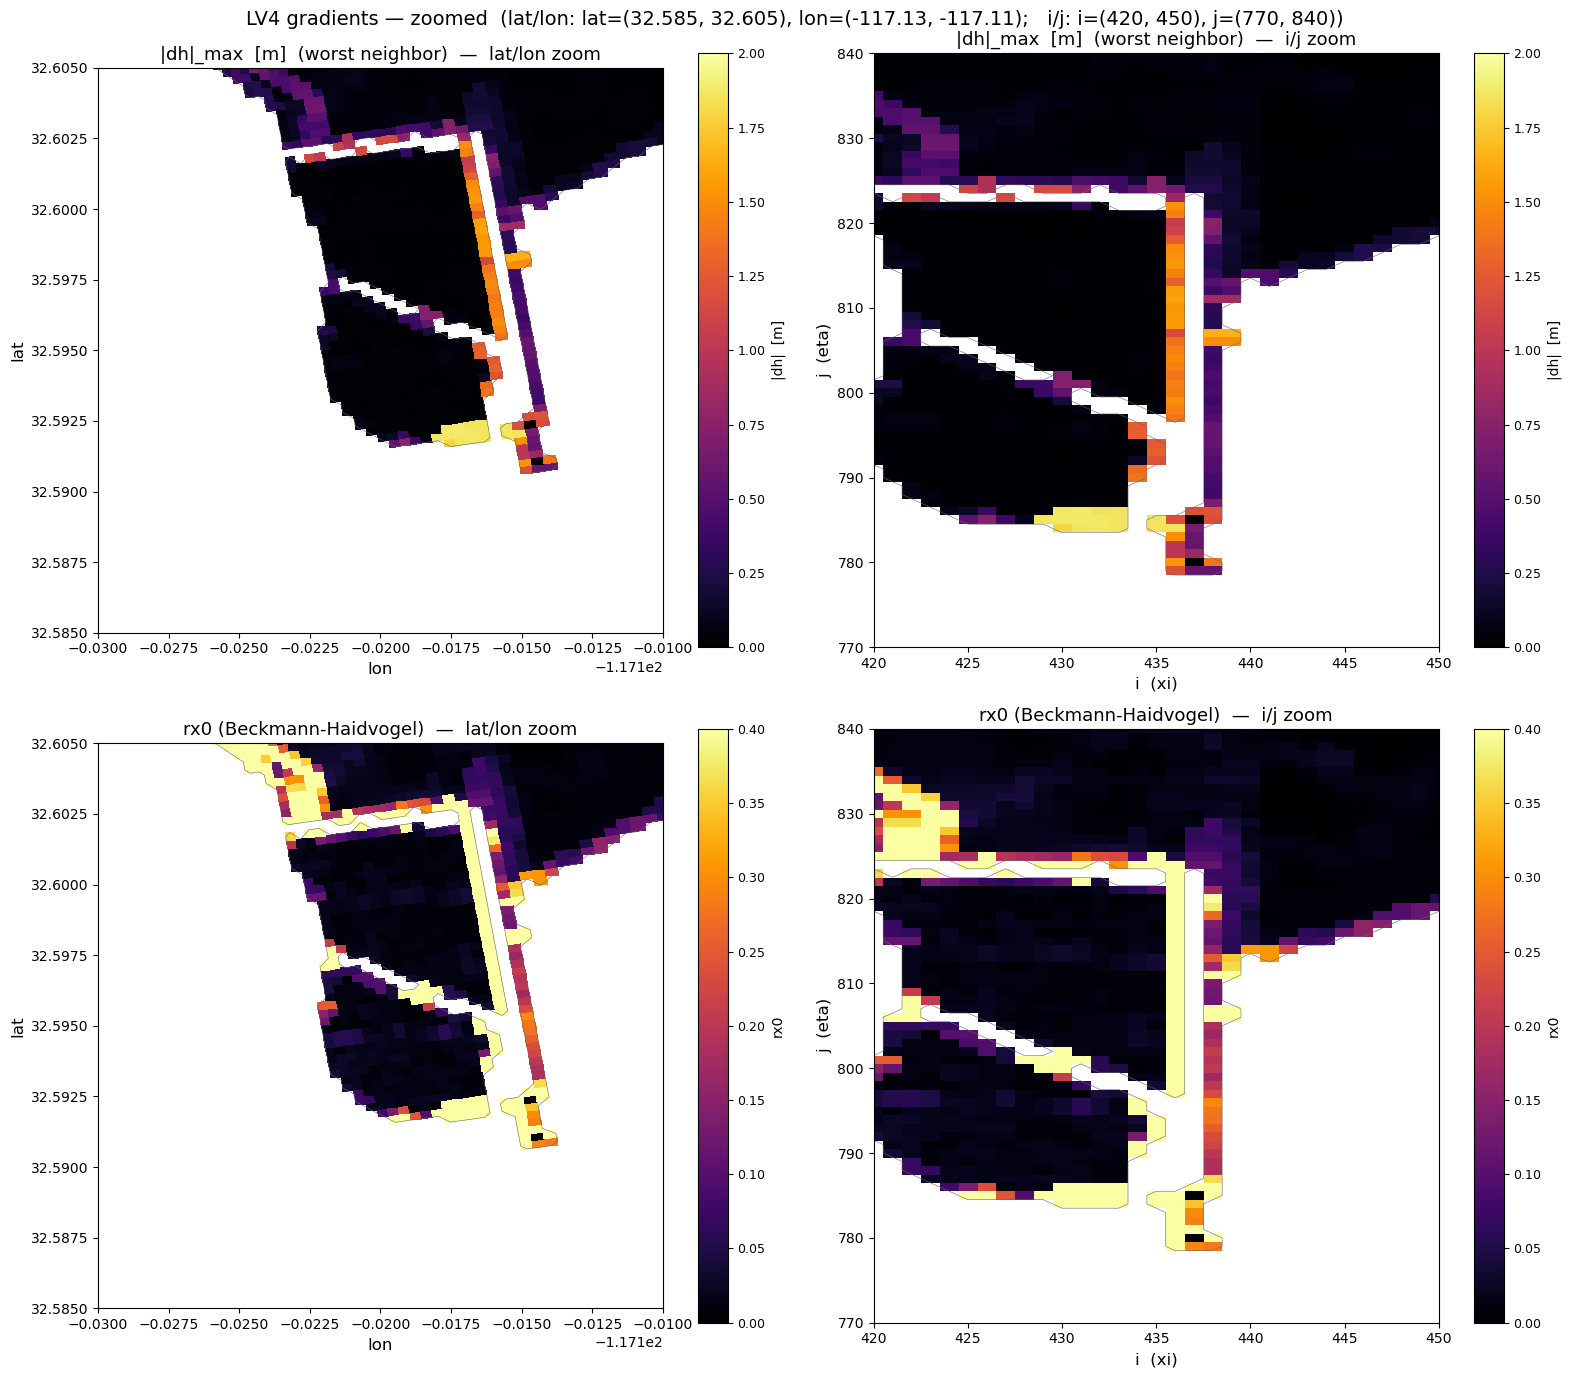

In [ ]:
# Same 2x2 view as above, zoomed to specific windows:
#   lat/lon window: lat = [32.525, 32.610],  lon = [-117.14, -117.10]
#   i/j     window: j   = [400, 850],        i   = [300, 450]
# (independent windows — they may not cover the same physical area.)

LL_YLIM = (32.585, 32.605)
LL_XLIM = (-117.13, -117.11)
IJ_YLIM = (770, 840)
IJ_XLIM = (420, 450)

LBL_FS, TICK_FS, TITLE_FS = 12, 10, 14

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

specs = [
    (dh_rho,  '|dh|_max  [m]  (worst neighbor)', 'inferno', 0, 2.0, '|dh|  [m]'),
    (rx0_rho, 'rx0 (Beckmann-Haidvogel)',        'inferno', 0, 0.4, 'rx0'),
]

for row, (field, ttl, cmap, vmn, vmx, lbl) in enumerate(specs):
    # left column: lat/lon
    ax = axes[row, 0]
    pc = ax.pcolormesh(lon, lat, wet_only(field), cmap=cmap, vmin=vmn, vmax=vmx,
                       shading='auto')
    ax.contour(lon, lat, mask, levels=[0.5], colors='0.4', linewidths=0.4)
    ax.plot(lon[BU_J, BU_I],     lat[BU_J, BU_I],     'o', ms=14, mfc='none',
            mec='limegreen', mew=2.5)
    cb = fig.colorbar(pc, ax=ax, label=lbl)
    cb.ax.tick_params(labelsize=TICK_FS-1)
    ax.set_xlim(LL_XLIM); ax.set_ylim(LL_YLIM)
    ax.set_xlabel('lon', fontsize=LBL_FS); ax.set_ylabel('lat', fontsize=LBL_FS)
    ax.set_title(f'{ttl}  —  lat/lon zoom', fontsize=TITLE_FS-1)
    ax.tick_params(labelsize=TICK_FS)
    ax.set_aspect('equal')

    # right column: i/j
    ax = axes[row, 1]
    pc = ax.imshow(wet_only(field), origin='lower', cmap=cmap, vmin=vmn, vmax=vmx,
                   interpolation='nearest', aspect='auto')
    ax.contour(np.arange(nx), np.arange(ny), mask, levels=[0.5],
               colors='0.4', linewidths=0.4)
    ax.plot(BU_I, BU_J, 'o', ms=14, mfc='none', mec='limegreen', mew=2.5)
    cb = fig.colorbar(pc, ax=ax, label=lbl)
    cb.ax.tick_params(labelsize=TICK_FS-1)
    ax.set_xlim(IJ_XLIM); ax.set_ylim(IJ_YLIM)
    ax.set_xlabel('i  (xi)', fontsize=LBL_FS); ax.set_ylabel('j  (eta)', fontsize=LBL_FS)
    ax.set_title(f'{ttl}  —  i/j zoom', fontsize=TITLE_FS-1)
    ax.tick_params(labelsize=TICK_FS)

fig.suptitle('LV4 gradients — zoomed  '
             f'(lat/lon: lat={LL_YLIM}, lon={LL_XLIM};   i/j: i={IJ_XLIM}, j={IJ_YLIM})',
             fontsize=TITLE_FS)
fig.tight_layout()
plt.show()


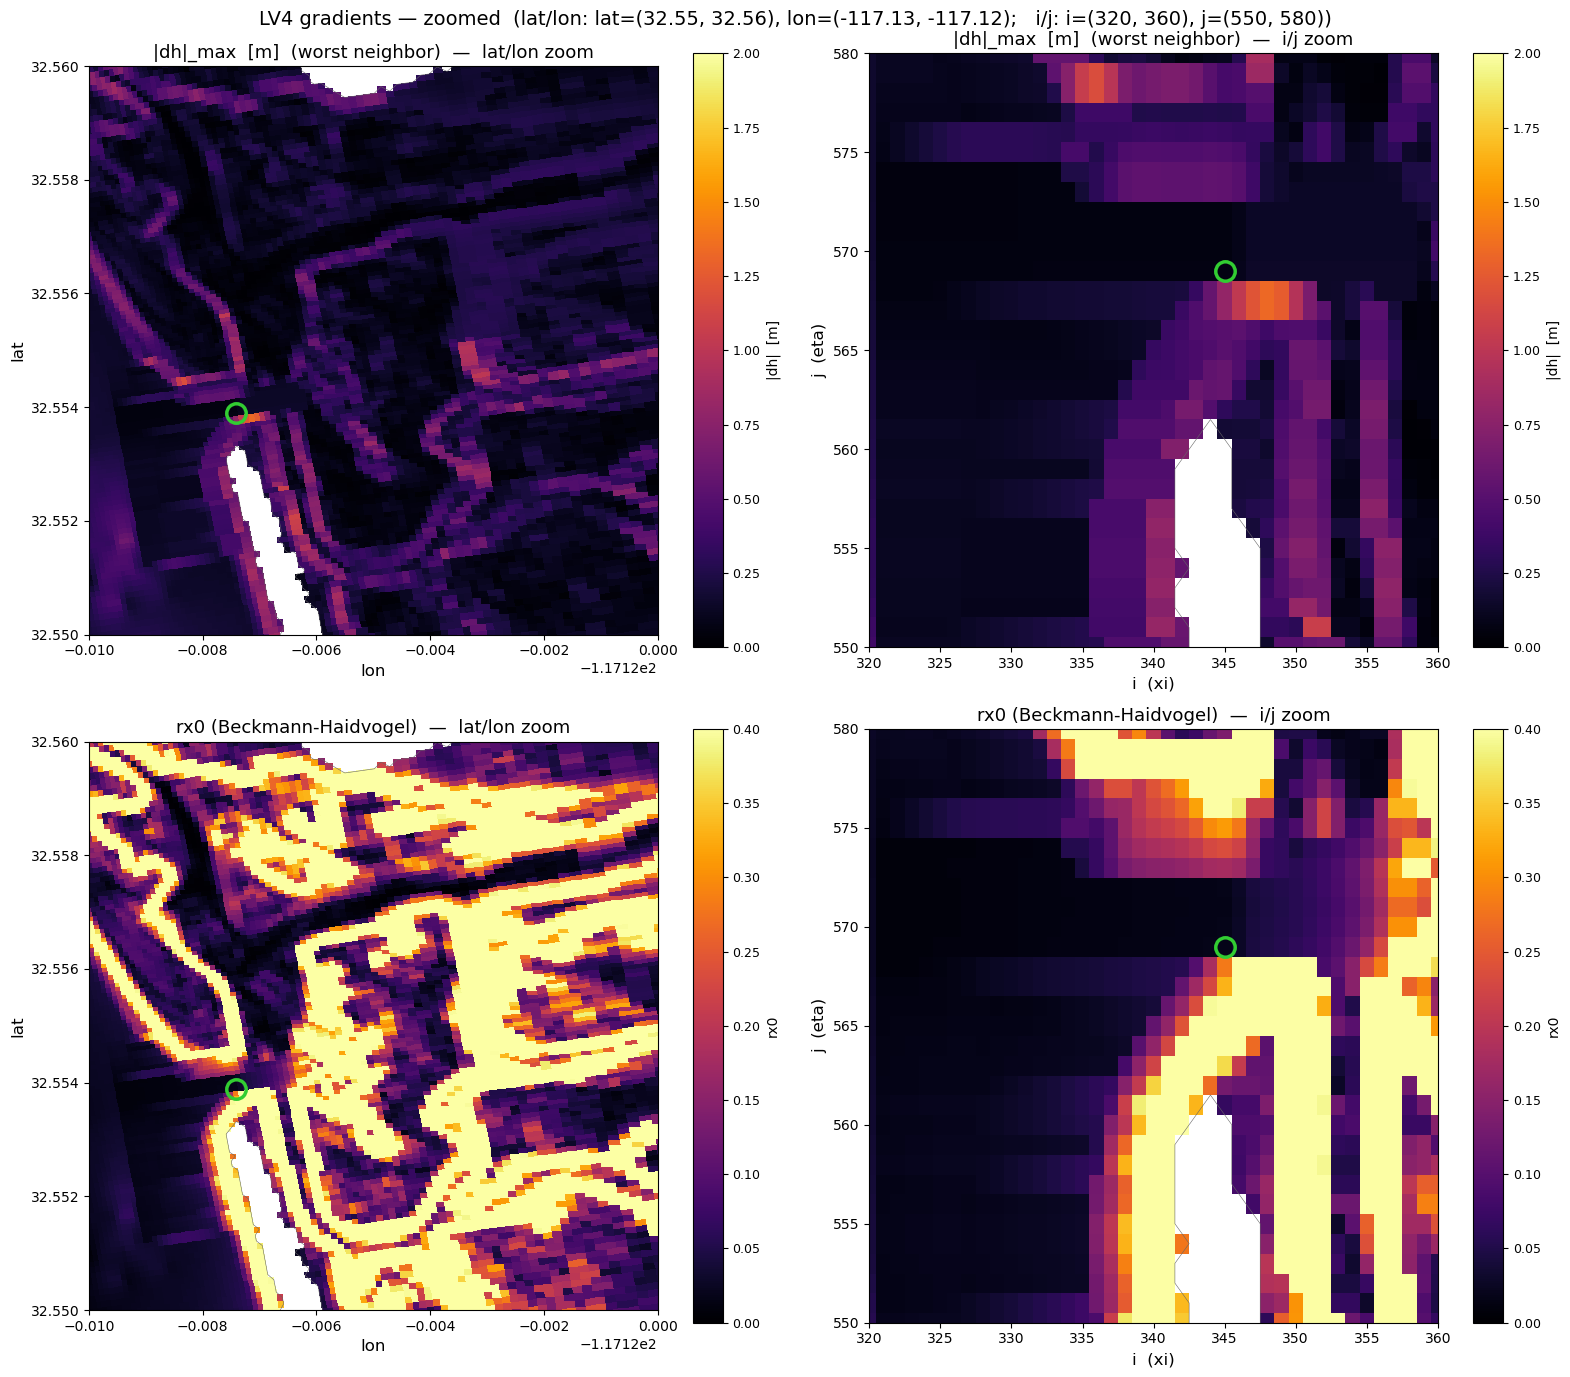

In [23]:
# Same 2x2 view as above, zoomed to specific windows:
#   lat/lon window: lat = [32.525, 32.610],  lon = [-117.14, -117.10]
#   i/j     window: j   = [400, 850],        i   = [300, 450]
# (independent windows — they may not cover the same physical area.)

LL_YLIM = (32.55, 32.56)
LL_XLIM = (-117.13, -117.12)
IJ_YLIM = (550, 580)
IJ_XLIM = (320, 360)

LBL_FS, TICK_FS, TITLE_FS = 12, 10, 14

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

specs = [
    (dh_rho,  '|dh|_max  [m]  (worst neighbor)', 'inferno', 0, 2.0, '|dh|  [m]'),
    (rx0_rho, 'rx0 (Beckmann-Haidvogel)',        'inferno', 0, 0.4, 'rx0'),
]

for row, (field, ttl, cmap, vmn, vmx, lbl) in enumerate(specs):
    # left column: lat/lon
    ax = axes[row, 0]
    pc = ax.pcolormesh(lon, lat, wet_only(field), cmap=cmap, vmin=vmn, vmax=vmx,
                       shading='auto')
    ax.contour(lon, lat, mask, levels=[0.5], colors='0.4', linewidths=0.4)
    ax.plot(lon[BU_J, BU_I],     lat[BU_J, BU_I],     'o', ms=14, mfc='none',
            mec='limegreen', mew=2.5)
    cb = fig.colorbar(pc, ax=ax, label=lbl)
    cb.ax.tick_params(labelsize=TICK_FS-1)
    ax.set_xlim(LL_XLIM); ax.set_ylim(LL_YLIM)
    ax.set_xlabel('lon', fontsize=LBL_FS); ax.set_ylabel('lat', fontsize=LBL_FS)
    ax.set_title(f'{ttl}  —  lat/lon zoom', fontsize=TITLE_FS-1)
    ax.tick_params(labelsize=TICK_FS)
    ax.set_aspect('equal')

    # right column: i/j
    ax = axes[row, 1]
    pc = ax.imshow(wet_only(field), origin='lower', cmap=cmap, vmin=vmn, vmax=vmx,
                   interpolation='nearest', aspect='auto')
    ax.contour(np.arange(nx), np.arange(ny), mask, levels=[0.5],
               colors='0.4', linewidths=0.4)
    ax.plot(BU_I, BU_J, 'o', ms=14, mfc='none', mec='limegreen', mew=2.5)
    cb = fig.colorbar(pc, ax=ax, label=lbl)
    cb.ax.tick_params(labelsize=TICK_FS-1)
    ax.set_xlim(IJ_XLIM); ax.set_ylim(IJ_YLIM)
    ax.set_xlabel('i  (xi)', fontsize=LBL_FS); ax.set_ylabel('j  (eta)', fontsize=LBL_FS)
    ax.set_title(f'{ttl}  —  i/j zoom', fontsize=TITLE_FS-1)
    ax.tick_params(labelsize=TICK_FS)

fig.suptitle('LV4 gradients — zoomed  '
             f'(lat/lon: lat={LL_YLIM}, lon={LL_XLIM};   i/j: i={IJ_XLIM}, j={IJ_YLIM})',
             fontsize=TITLE_FS)
fig.tight_layout()
plt.show()

In [ ]:
# Zoom on the user-recalled patch region  (ROMS 1-idx  i=430, j=800  =>  py (429, 799))
CI_ROMS, CJ_ROMS = 430, 800
CI, CJ = CI_ROMS - 1, CJ_ROMS - 1
HALF = 15

i0, i1 = max(0, CI - HALF), min(nx - 1, CI + HALF)
j0, j1 = max(0, CJ - HALF), min(ny - 1, CJ + HALF)
extent = [i0, i1, j0, j1]

h_z    = h_old[j0:j1+1, i0:i1+1]
dh_z   = dh_rho[j0:j1+1, i0:i1+1]
rx0_z  = rx0_rho[j0:j1+1, i0:i1+1]
mask_z = mask[j0:j1+1, i0:i1+1]

print(f'zoom box: xi=[{i0},{i1}]  eta=[{j0},{j1}]   ({i1-i0+1} x {j1-j0+1} cells)')
print(f'center cell (ROMS {CI_ROMS},{CJ_ROMS}):')
print(f'  lon={lon[CJ,CI]:.4f}  lat={lat[CJ,CI]:.4f}  h_old={h_old[CJ,CI]:.3f}  mask={mask[CJ,CI]}')
print(f'  |dh|_max local = {dh_z.max():.3f} m   rx0_max local = {rx0_z.max():.3f}')

LBL_FS, TICK_FS, TITLE_FS = 12, 10, 14
fig, axes = plt.subplots(1, 3, figsize=(19, 7), sharex=True, sharey=True)

panels = [
    (axes[0], h_z,   f'h_old  [m]',                        'terrain',
        float(h_z.min()), float(h_z.max()), 'h  [m]'),
    (axes[1], dh_z,  '|dh|_max  [m]  (worst-neighbor)',    'inferno',
        0.0, float(dh_z.max()), '|dh|  [m]'),
    (axes[2], rx0_z, 'rx0  (Beckmann-Haidvogel)',          'inferno',
        0.0, float(max(rx0_z.max(), 0.3)), 'rx0'),
]

for ax, dat, ttl, cmap, vmn, vmx, lbl in panels:
    pc = ax.imshow(dat, origin='lower', cmap=cmap, vmin=vmn, vmax=vmx,
                   extent=extent, interpolation='nearest', aspect='auto')
    ax.contour(np.arange(i0, i1+1), np.arange(j0, j1+1), mask_z,
               levels=[0.5], colors='0.4', linewidths=0.6)
    ax.plot(CI, CJ, 'x', ms=16, mec='red', mew=3, label=f'ROMS ({CI_ROMS},{CJ_ROMS})')
    ax.legend(loc='upper right', fontsize=TICK_FS)
    cb = fig.colorbar(pc, ax=ax, label=lbl, fraction=0.045, pad=0.02)
    cb.ax.tick_params(labelsize=TICK_FS-1)
    ax.set_xlabel('i  (xi index)', fontsize=LBL_FS)
    ax.set_ylabel('j  (eta index)', fontsize=LBL_FS)
    ax.set_title(ttl, fontsize=TITLE_FS-1)
    ax.tick_params(labelsize=TICK_FS)

fig.suptitle(f'Zoom on user-recalled patch region  —  ROMS(i,j)=({CI_ROMS},{CJ_ROMS})  '
             f'lon={lon[CJ,CI]:.4f}  lat={lat[CJ,CI]:.4f}', fontsize=TITLE_FS)
fig.tight_layout()
plt.show()

## 1. Where did the depth change? Map of `dh = h_new - h_old`

Only wet cells that changed are colored; everywhere else is transparent/white.

blowup: (i=345, j=569)  lon=-117.1274  lat=32.5539  h_old=1.826  h_new=1.826


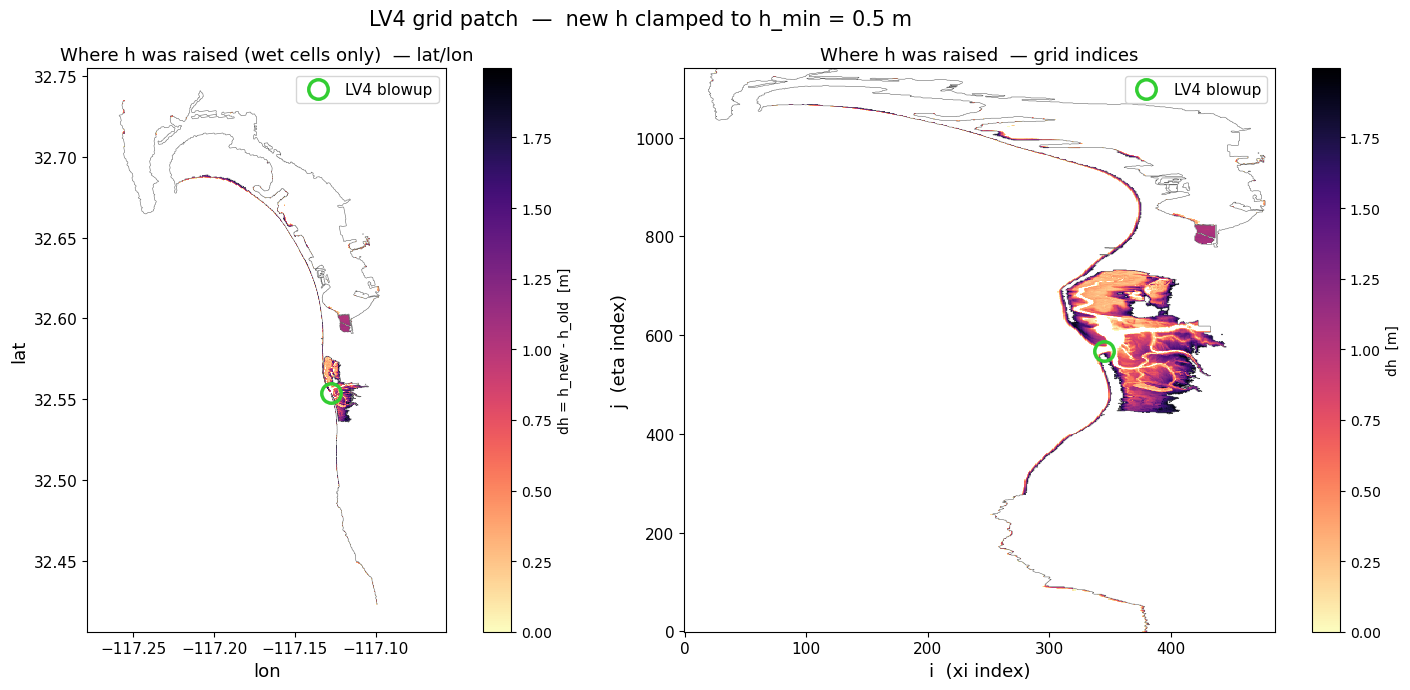

In [ ]:
# mask dh for display: show only wet cells that actually changed
dh_wet_changed = np.where(wet & (dh > 0), dh, np.nan)

# LV4 blowup location, from /scratch/PFM_Simulations/LV4_Forecast/Run/LV4_forecast.log
# step 103068, model time 2026-07-14 09:15:36 UTC
# ROMS 1-indexed (i=346, j=570) -> python 0-indexed (i=345, j=569)
BU_I, BU_J = 345, 569
BU_LON, BU_LAT = float(lon[BU_J, BU_I]), float(lat[BU_J, BU_I])
print(f'blowup: (i={BU_I}, j={BU_J})  lon={BU_LON:.4f}  lat={BU_LAT:.4f}  '
      f'h_old={h_old[BU_J, BU_I]:.3f}  h_new={h_new[BU_J, BU_I]:.3f}')

LBL_FS, TICK_FS, TITLE_FS = 13, 11, 15
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- (a) lat / lon view -----------------------------------------------------
ax = axes[0]
pc = ax.pcolormesh(lon, lat, dh_wet_changed, cmap='magma_r',
                   vmin=0, vmax=float(np.nanmax(dh_wet_changed)), shading='auto')
# coast outline from the original mask
ax.contour(lon, lat, mask, levels=[0.5], colors='0.4', linewidths=0.4)
# blowup marker
ax.plot(BU_LON, BU_LAT, 'o', ms=14, mfc='none', mec='limegreen',
        mew=2.5, label='LV4 blowup')
ax.legend(loc='upper right', fontsize=TICK_FS)
cb = fig.colorbar(pc, ax=ax, label='dh = h_new - h_old  [m]')
cb.ax.tick_params(labelsize=TICK_FS-1)
ax.set_xlabel('lon', fontsize=LBL_FS); ax.set_ylabel('lat', fontsize=LBL_FS)
ax.set_title('Where h was raised (wet cells only)  — lat/lon', fontsize=TITLE_FS-2)
ax.tick_params(labelsize=TICK_FS)
ax.set_aspect('equal')

# --- (b) i / j view --------------------------------------------------------
ax = axes[1]
pc = ax.imshow(dh_wet_changed, origin='lower', cmap='magma_r',
               vmin=0, vmax=float(np.nanmax(dh_wet_changed)),
               interpolation='nearest', aspect='auto')
# coast outline in index space
ax.contour(np.arange(nx), np.arange(ny), mask, levels=[0.5],
           colors='0.4', linewidths=0.4)
# blowup marker
ax.plot(BU_I, BU_J, 'o', ms=14, mfc='none', mec='limegreen',
        mew=2.5, label='LV4 blowup')
ax.legend(loc='upper right', fontsize=TICK_FS)
cb = fig.colorbar(pc, ax=ax, label='dh  [m]')
cb.ax.tick_params(labelsize=TICK_FS-1)
ax.set_xlabel('i  (xi index)', fontsize=LBL_FS)
ax.set_ylabel('j  (eta index)', fontsize=LBL_FS)
ax.set_title('Where h was raised  — grid indices', fontsize=TITLE_FS-2)
ax.tick_params(labelsize=TICK_FS)

fig.suptitle('LV4 grid patch  —  new h clamped to h_min = 0.5 m', fontsize=TITLE_FS)
fig.tight_layout()
plt.show()


blowup: (i=345, j=569)  lon=-117.1274  lat=32.5539  h_old=1.826  h_new=1.826


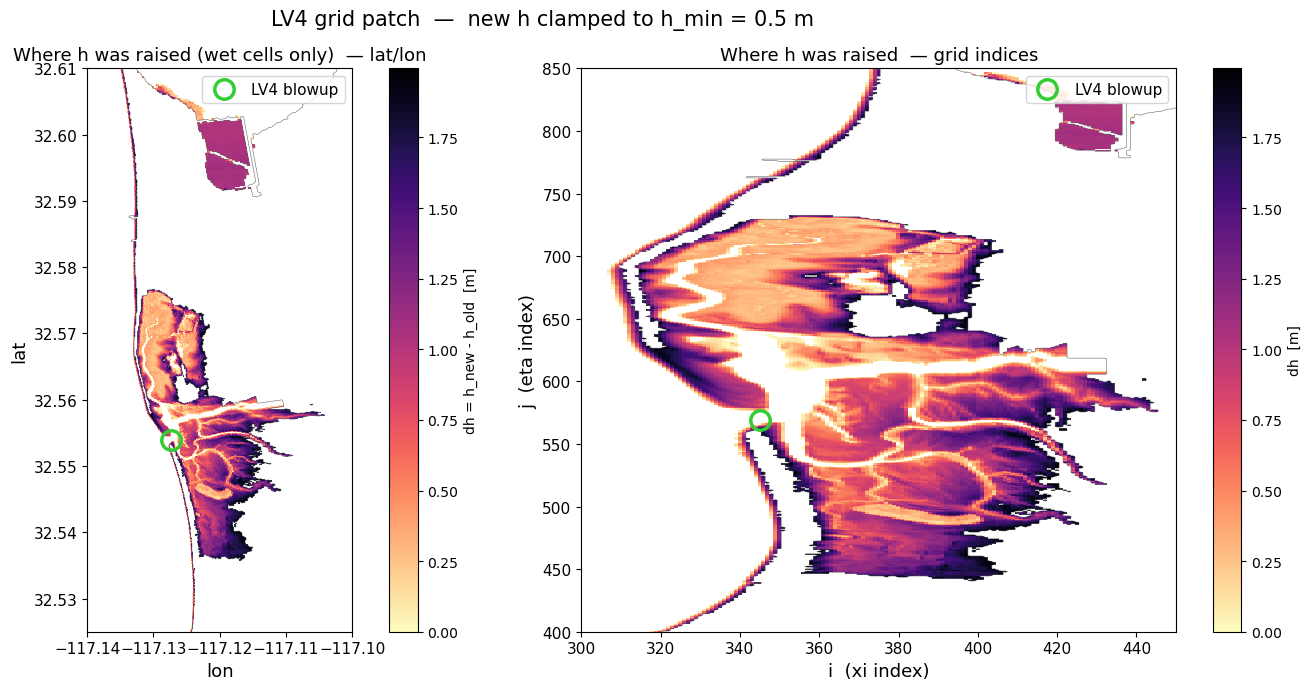

In [13]:
# mask dh for display: show only wet cells that actually changed
dh_wet_changed = np.where(wet & (dh > 0), dh, np.nan)

# LV4 blowup location, from /scratch/PFM_Simulations/LV4_Forecast/Run/LV4_forecast.log
# step 103068, model time 2026-07-14 09:15:36 UTC
# ROMS 1-indexed (i=346, j=570) -> python 0-indexed (i=345, j=569)
BU_I, BU_J = 345, 569
BU_LON, BU_LAT = float(lon[BU_J, BU_I]), float(lat[BU_J, BU_I])
print(f'blowup: (i={BU_I}, j={BU_J})  lon={BU_LON:.4f}  lat={BU_LAT:.4f}  '
      f'h_old={h_old[BU_J, BU_I]:.3f}  h_new={h_new[BU_J, BU_I]:.3f}')

LBL_FS, TICK_FS, TITLE_FS = 13, 11, 15
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- (a) lat / lon view -----------------------------------------------------
ax = axes[0]
pc = ax.pcolormesh(lon, lat, dh_wet_changed, cmap='magma_r',
                   vmin=0, vmax=float(np.nanmax(dh_wet_changed)), shading='auto')
# coast outline from the original mask
ax.contour(lon, lat, mask, levels=[0.5], colors='0.4', linewidths=0.4)
# blowup marker
ax.plot(BU_LON, BU_LAT, 'o', ms=14, mfc='none', mec='limegreen',
        mew=2.5, label='LV4 blowup')
ax.legend(loc='upper right', fontsize=TICK_FS)
cb = fig.colorbar(pc, ax=ax, label='dh = h_new - h_old  [m]')
cb.ax.tick_params(labelsize=TICK_FS-1)
ax.set_xlabel('lon', fontsize=LBL_FS); ax.set_ylabel('lat', fontsize=LBL_FS)
ax.set_title('Where h was raised (wet cells only)  — lat/lon', fontsize=TITLE_FS-2)
ax.tick_params(labelsize=TICK_FS)
ax.set_ylim([32.525,32.61])
ax.set_xlim([-117.14,-117.1])
ax.set_aspect('equal')

# --- (b) i / j view --------------------------------------------------------
ax = axes[1]
pc = ax.imshow(dh_wet_changed, origin='lower', cmap='magma_r',
               vmin=0, vmax=float(np.nanmax(dh_wet_changed)),
               interpolation='nearest', aspect='auto')
# coast outline in index space
ax.contour(np.arange(nx), np.arange(ny), mask, levels=[0.5],
           colors='0.4', linewidths=0.4)
# blowup marker
ax.plot(BU_I, BU_J, 'o', ms=14, mfc='none', mec='limegreen',
        mew=2.5, label='LV4 blowup')
ax.legend(loc='upper right', fontsize=TICK_FS)
cb = fig.colorbar(pc, ax=ax, label='dh  [m]')
cb.ax.tick_params(labelsize=TICK_FS-1)
ax.set_xlabel('i  (xi index)', fontsize=LBL_FS)
ax.set_ylabel('j  (eta index)', fontsize=LBL_FS)
ax.set_title('Where h was raised  — grid indices', fontsize=TITLE_FS-2)
ax.tick_params(labelsize=TICK_FS)
ax.set_ylim([400,850])
ax.set_xlim([300,450])


fig.suptitle('LV4 grid patch  —  new h clamped to h_min = 0.5 m', fontsize=TITLE_FS)
fig.tight_layout()
plt.show()

## 2. Side-by-side: `h_old` vs `h_new` vs `dh`, zoomed to SD Bay + TJ Estuary

The changes cluster in SD Bay's shallow interior and along the TJ Estuary intertidal, so we zoom there. Log-color both `h` panels so shallow structure is visible.

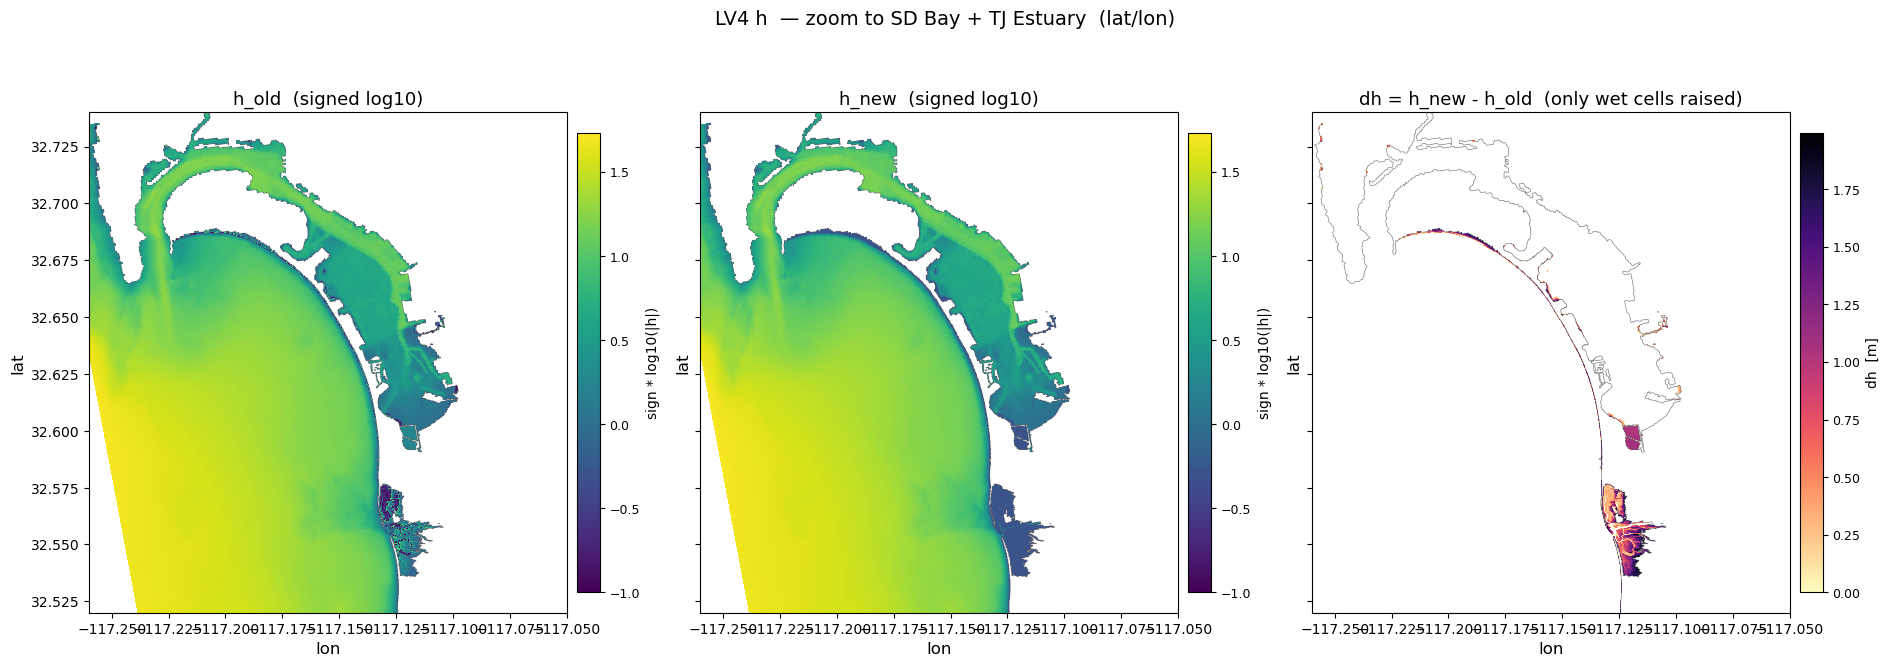

In [8]:
# zoom bbox
LAT0, LAT1 = 32.52, 32.74
LON0, LON1 = -117.26, -117.05

in_zoom = (lat >= LAT0) & (lat <= LAT1) & (lon >= LON0) & (lon <= LON1)
# use a signed-log for h (so h<0 in the original is legible)
def signed_log(x, thr=0.1):
    x = np.asarray(x, float)
    s = np.sign(x)
    return s * np.log10(np.maximum(np.abs(x), thr))

h_old_disp = np.where(wet, signed_log(h_old), np.nan)
h_new_disp = np.where(wet, signed_log(h_new), np.nan)
vmn = min(np.nanmin(h_old_disp[in_zoom]), np.nanmin(h_new_disp[in_zoom]))
vmx = max(np.nanmax(h_old_disp[in_zoom]), np.nanmax(h_new_disp[in_zoom]))

LBL_FS, TICK_FS, TITLE_FS = 12, 10, 14
fig, axes = plt.subplots(1, 3, figsize=(19, 7), sharex=True, sharey=True)

for ax, dat, ttl, cmap, vlo, vhi, lbl in [
    (axes[0], h_old_disp, 'h_old  (signed log10)', 'viridis', vmn, vmx, 'sign * log10(|h|)'),
    (axes[1], h_new_disp, 'h_new  (signed log10)', 'viridis', vmn, vmx, 'sign * log10(|h|)'),
    (axes[2], np.where(wet & (dh>0), dh, np.nan),
                          'dh = h_new - h_old  (only wet cells raised)', 'magma_r',
                          0, float(np.nanmax(np.where(wet&(dh>0)&in_zoom, dh, 0))),
                          'dh  [m]'),
]:
    pc = ax.pcolormesh(lon, lat, dat, cmap=cmap, vmin=vlo, vmax=vhi, shading='auto')
    ax.contour(lon, lat, mask, levels=[0.5], colors='0.4', linewidths=0.4)
    cb = fig.colorbar(pc, ax=ax, label=lbl, fraction=0.045, pad=0.02)
    cb.ax.tick_params(labelsize=TICK_FS-1)
    ax.set_xlim(LON0, LON1); ax.set_ylim(LAT0, LAT1)
    ax.set_xlabel('lon', fontsize=LBL_FS); ax.set_ylabel('lat', fontsize=LBL_FS)
    ax.set_title(ttl, fontsize=TITLE_FS-1)
    ax.tick_params(labelsize=TICK_FS)
    ax.set_aspect('equal')

fig.suptitle('LV4 h  \u2014 zoom to SD Bay + TJ Estuary  (lat/lon)', fontsize=TITLE_FS)
fig.tight_layout()
plt.show()

## 3. Same three-panel view in grid indices (i, j)

Zoom to the same region using index coordinates, useful for identifying cells and cross-checking against ROMS log messages (which report `(i, j, k)`).

In [ ]:
# derive an i/j zoom box from the lat/lon one
jj, ii = np.where(in_zoom)
I0, I1 = int(ii.min()), int(ii.max())
J0, J1 = int(jj.min()), int(jj.max())
print(f'zoom box in indices: xi=[{I0}, {I1}]   eta=[{J0}, {J1}]')

def crop(a):
    return a[J0:J1+1, I0:I1+1]

h_old_z = crop(h_old_disp)
h_new_z = crop(h_new_disp)
dh_z    = crop(np.where(wet & (dh>0), dh, np.nan))
mask_z  = crop(mask)

extent = [I0, I1, J0, J1]

LBL_FS, TICK_FS, TITLE_FS = 12, 10, 14
fig, axes = plt.subplots(1, 3, figsize=(19, 7), sharex=True, sharey=True)

for ax, dat, ttl, cmap, vlo, vhi, lbl in [
    (axes[0], h_old_z, 'h_old  (signed log10)', 'viridis', vmn, vmx, 'sign * log10(|h|)'),
    (axes[1], h_new_z, 'h_new  (signed log10)', 'viridis', vmn, vmx, 'sign * log10(|h|)'),
    (axes[2], dh_z,   'dh  (only wet cells raised)', 'magma_r',
                       0, float(np.nanmax(dh_z)) if np.isfinite(np.nanmax(dh_z)) else 1.0,
                       'dh  [m]'),
]:
    pc = ax.imshow(dat, origin='lower', cmap=cmap, vmin=vlo, vmax=vhi,
                   extent=extent, interpolation='nearest', aspect='auto')
    ax.contour(np.arange(I0, I1+1), np.arange(J0, J1+1), mask_z,
               levels=[0.5], colors='0.4', linewidths=0.4)
    cb = fig.colorbar(pc, ax=ax, label=lbl, fraction=0.045, pad=0.02)
    cb.ax.tick_params(labelsize=TICK_FS-1)
    ax.set_xlabel('i  (xi index)', fontsize=LBL_FS)
    ax.set_ylabel('j  (eta index)', fontsize=LBL_FS)
    ax.set_title(ttl, fontsize=TITLE_FS-1)
    ax.tick_params(labelsize=TICK_FS)

fig.suptitle('LV4 h  \u2014 zoom to SD Bay + TJ Estuary  (grid indices)', fontsize=TITLE_FS)
fig.tight_layout()
plt.show()

zoom box in indices: xi=[0, 485]   eta=[349, 1140]


KeyboardInterrupt: 

## 4. Histogram of the change

Distribution of `dh` across the wet cells that got raised. Confirms the operation was `max(h, 0.5)` and not a uniform offset.

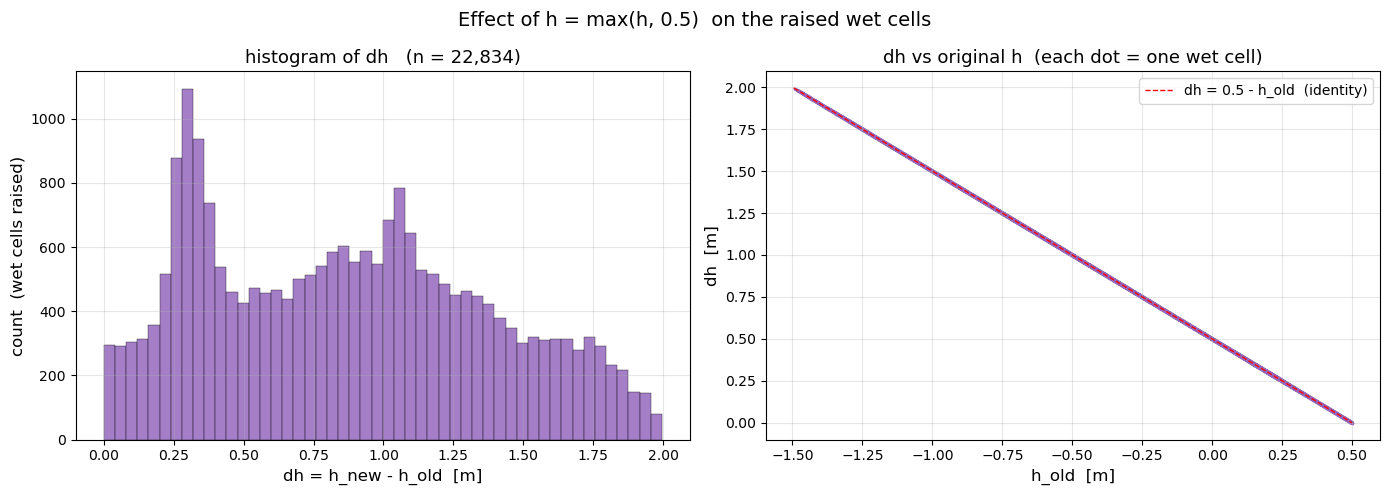

In [5]:
changed_wet = wet & (dh > 0)
vals = dh[changed_wet]
h_old_vals = h_old[changed_wet]

LBL_FS, TICK_FS, TITLE_FS = 12, 10, 14
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(vals, bins=50, color='tab:purple', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.set_xlabel('dh = h_new - h_old  [m]', fontsize=LBL_FS)
ax.set_ylabel('count  (wet cells raised)', fontsize=LBL_FS)
ax.set_title(f'histogram of dh   (n = {len(vals):,})', fontsize=TITLE_FS-1)
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(h_old_vals, dh[changed_wet], s=2, alpha=0.3, color='tab:purple')
# theoretical line: dh = 0.5 - h_old when h_old < 0.5
xline = np.linspace(h_old_vals.min(), 0.5, 200)
ax.plot(xline, 0.5 - xline, 'r--', lw=1, label='dh = 0.5 - h_old  (identity)')
ax.set_xlabel('h_old  [m]', fontsize=LBL_FS)
ax.set_ylabel('dh  [m]', fontsize=LBL_FS)
ax.set_title('dh vs original h  (each dot = one wet cell)', fontsize=TITLE_FS-1)
ax.legend(fontsize=TICK_FS)
ax.grid(alpha=0.3)

fig.suptitle('Effect of h = max(h, 0.5)  on the raised wet cells', fontsize=TITLE_FS)
fig.tight_layout()
plt.show()